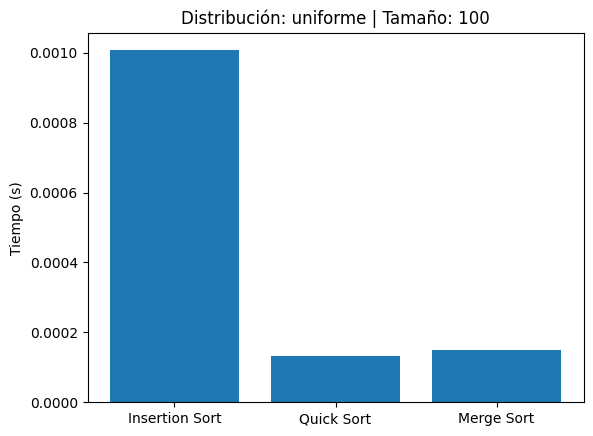

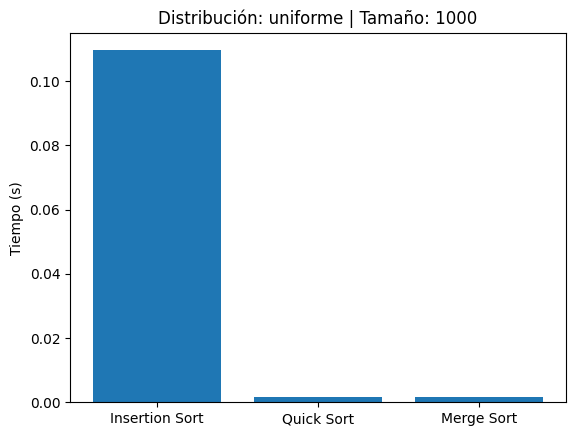

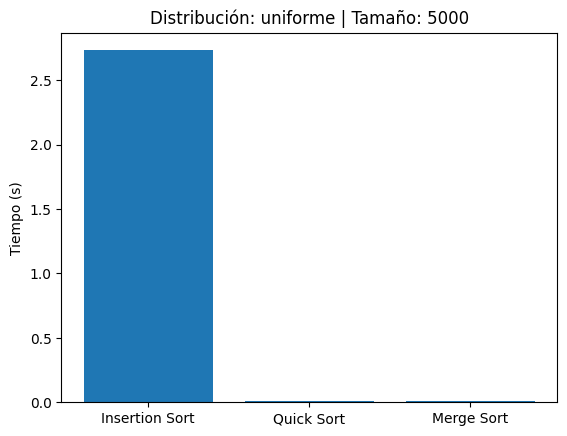

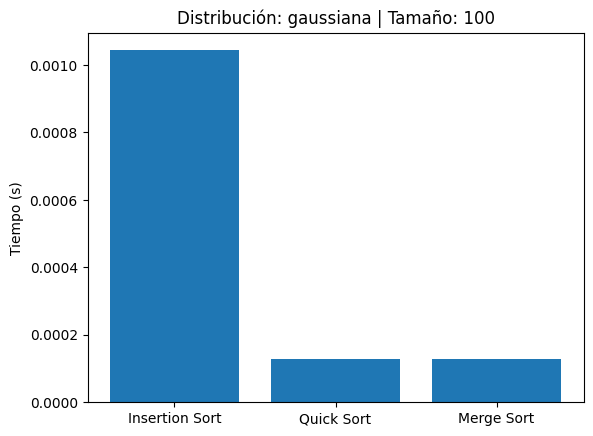

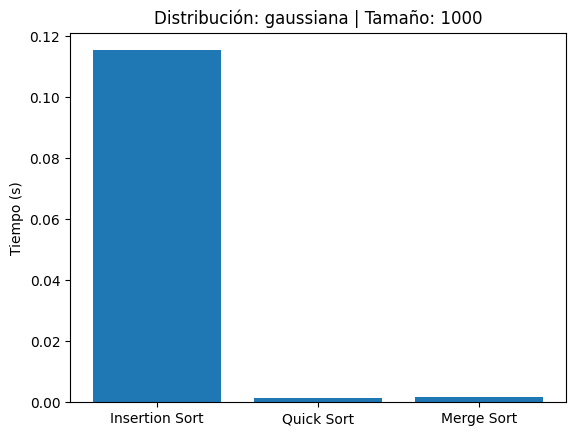

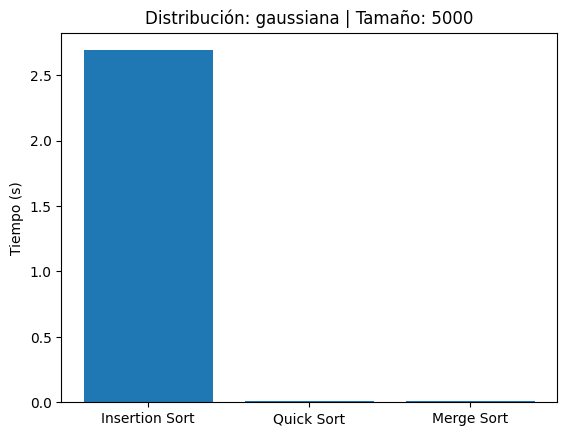

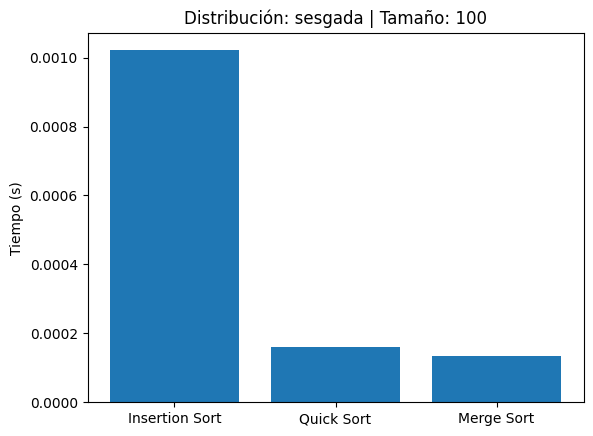

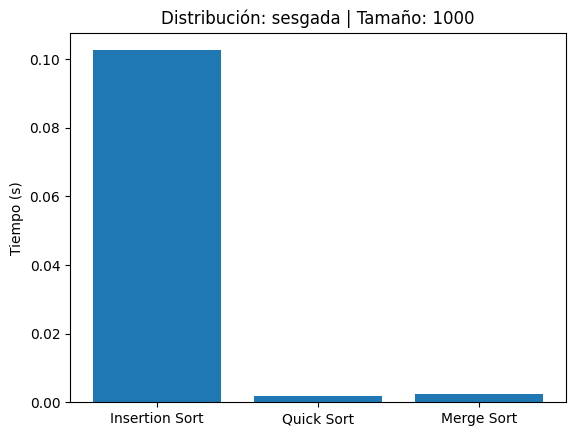

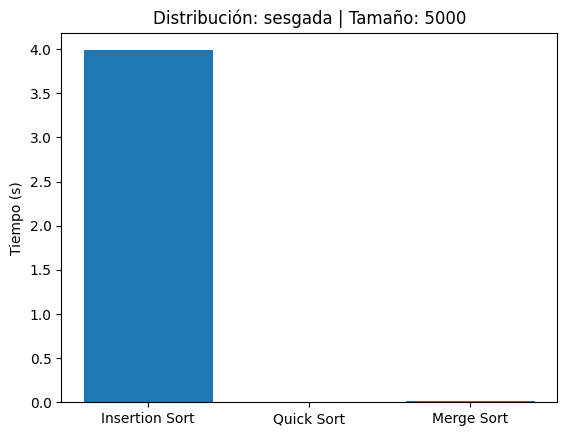

✅ Guardado: datasets/uniforme_100.csv
✅ Guardado: datasets/uniforme_1000.csv
✅ Guardado: datasets/uniforme_10000.csv
✅ Guardado: datasets/gaussiana_100.csv
✅ Guardado: datasets/gaussiana_1000.csv
✅ Guardado: datasets/gaussiana_10000.csv
✅ Guardado: datasets/sesgada_100.csv
✅ Guardado: datasets/sesgada_1000.csv
✅ Guardado: datasets/sesgada_10000.csv


In [4]:
# ===============================================
#   Taller desarrollado por: Angel Nicolas Riaño Guzman - 1092363153
#                            Jhon Alexander Rodriguz Zapata - 100481106
#   Asignatura: Diseño Funcional
#   Tema: Vectores y Algoritmos de Búsqueda/Ordenamiento
#   Proyecto: Sistema de Gestión de Datos con Algoritmos Optimizados
# ===============================================

# ===============================
# IMPORTAR LIBRERÍAS
# ===============================
import numpy as np
import matplotlib.pyplot as plt
import time
import random

# ===============================
# MÓDULO 1 - GENERACIÓN DE DATOS
# ===============================
def generar_datos(distribucion, n):
    if distribucion == "uniforme":
        return np.random.randint(0, 10000, n)
    elif distribucion == "gaussiana":
        return np.random.normal(loc=5000, scale=2000, size=n).astype(int)
    elif distribucion == "sesgada":
        return np.random.exponential(scale=2000, size=n).astype(int)
    else:
        raise ValueError("Distribución no soportada")

# ===============================
# MÓDULO 2 - ALGORITMOS ORDENAMIENTO
# ===============================
def insertion_sort(arr):
    arr = arr.copy()
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        while j >= 0 and arr[j] > key:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = key
    return arr

def quick_sort(arr):
    if len(arr) <= 1:
        return arr
    pivot = arr[len(arr)//2]
    izquierda = [x for x in arr if x < pivot]
    centro = [x for x in arr if x == pivot]
    derecha = [x for x in arr if x > pivot]
    return quick_sort(izquierda) + centro + quick_sort(derecha)

def merge_sort(arr):
    if len(arr) > 1:
        mid = len(arr)//2
        L = arr[:mid]
        R = arr[mid:]
        merge_sort(L)
        merge_sort(R)
        i = j = k = 0
        while i < len(L) and j < len(R):
            if L[i] < R[j]:
                arr[k] = L[i]; i += 1
            else:
                arr[k] = R[j]; j += 1
            k += 1
        while i < len(L):
            arr[k] = L[i]; i += 1; k += 1
        while j < len(R):
            arr[k] = R[j]; j += 1; k += 1
    return arr

# ===============================
# MÓDULO 3 - BÚSQUEDAS
# ===============================
def busqueda_lineal(arr, objetivo):
    for i, val in enumerate(arr):
        if val == objetivo:
            return i
    return -1

def busqueda_binaria(arr, objetivo):
    izq, der = 0, len(arr)-1
    while izq <= der:
        mid = (izq+der)//2
        if arr[mid] == objetivo:
            return mid
        elif arr[mid] < objetivo:
            izq = mid + 1
        else:
            der = mid - 1
    return -1

# ===============================
# MÓDULO 4 - ANÁLISIS DE RENDIMIENTO
# ===============================
def medir_tiempo(algoritmo, datos):
    inicio = time.time()
    algoritmo(datos)
    fin = time.time()
    return fin - inicio

# ===============================
# MÓDULO 5 - EXPERIMENTOS Y VISUALIZACIÓN
# ===============================
distribuciones = ["uniforme", "gaussiana", "sesgada"]
tamaños = [100, 1000, 5000]

resultados = {}

for dist in distribuciones:
    resultados[dist] = {}
    for n in tamaños:
        datos = generar_datos(dist, n)
        tiempos = {
            "Insertion Sort": medir_tiempo(insertion_sort, datos),
            "Quick Sort": medir_tiempo(quick_sort, datos.tolist()),
            "Merge Sort": medir_tiempo(merge_sort, datos.tolist())
        }
        resultados[dist][n] = tiempos

# Graficar resultados
for dist in distribuciones:
    for n in tamaños:
        plt.bar(resultados[dist][n].keys(), resultados[dist][n].values())
        plt.title(f"Distribución: {dist} | Tamaño: {n}")
        plt.ylabel("Tiempo (s)")
        plt.show()


# ===============================
# MÓDULO EXTRA - EXPORTAR A CSV
# ===============================
import pandas as pd
import os

# Crear carpeta para guardar los CSV
os.makedirs("datasets", exist_ok=True)

tamaños = [100, 1000, 10000]
distribuciones = ["uniforme", "gaussiana", "sesgada"]

for dist in distribuciones:
    for n in tamaños:
        datos = generar_datos(dist, n)
        nombre_archivo = f"datasets/{dist}_{n}.csv"
        pd.DataFrame(datos, columns=["valor"]).to_csv(nombre_archivo, index=False)
        print(f"✅ Guardado: {nombre_archivo}")
